In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
print("Data Shape:", df.shape)
df.head()

Data Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


### 2.1 Load & Inspect

* **How many rows?** 
The dataset contains 187,531 rows.

* **Which columns are numeric vs text?**
  - **Numeric columns:** Index, Bathroom, Balcony (and any other numeric metrics).
  - **Text columns:** Title, Description, Amount (in rupees), Price (in rupees), location, Carpet Area, Status, Floor, Transaction, facing, overlooking, Society, Ownership, Super Area, Dimensions, Plot Area, Car Parking.

* **Which columns have the most missing values?**
Columns like Plot Area, overlooking, and facing have the highest percentage of missing values.

C:\Users\COMPUMARTS\AppData\Local\Temp\ipykernel_20208\3864236109.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[df['location'].isin(top_locations)]['location'], order=top_locations, palette='viridis')


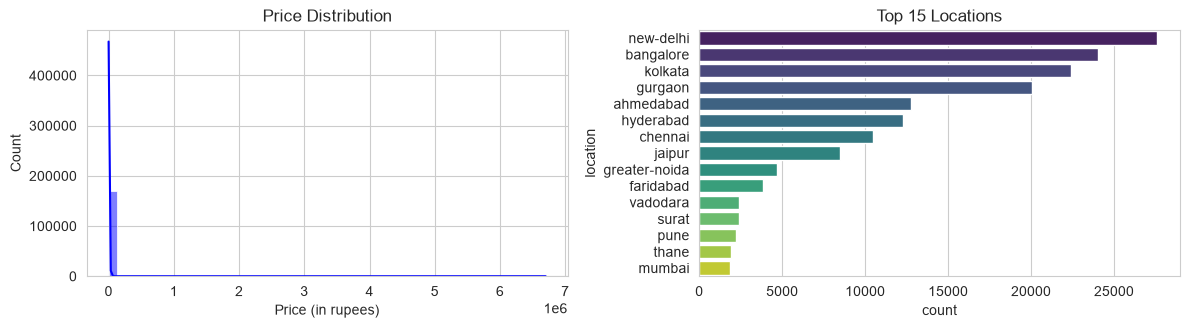

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
sns.histplot(df["Price (in rupees)"], kde=True, bins=50, color='blue')
plt.title("Price Distribution")

plt.subplot(2, 2, 2)
top_locations = df['location'].value_counts().head(15).index
sns.countplot(y=df[df['location'].isin(top_locations)]['location'], order=top_locations, palette='viridis')
plt.title("Top 15 Locations")

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Clean columns and convert them safely to numeric, forcing text/invalid entries to NaN
clean_df = pd.DataFrame()
clean_df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')
clean_df['Price'] = pd.to_numeric(df['Price (in rupees)'], errors='coerce')

# Drop rows with missing values
clean_df = clean_df.dropna()

X = clean_df[['Bathroom']]
y = clean_df['Price']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict house prices on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance
print("--- Model Performance ---")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

--- Model Performance ---
R2 Score: 0.1081663538351072
RMSE: 4562.610553044929


C:\Users\COMPUMARTS\AppData\Local\Temp\ipykernel_20208\3222646624.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Price_Clean', y='location', data=top_15_df, errorbar=None, palette='viridis')


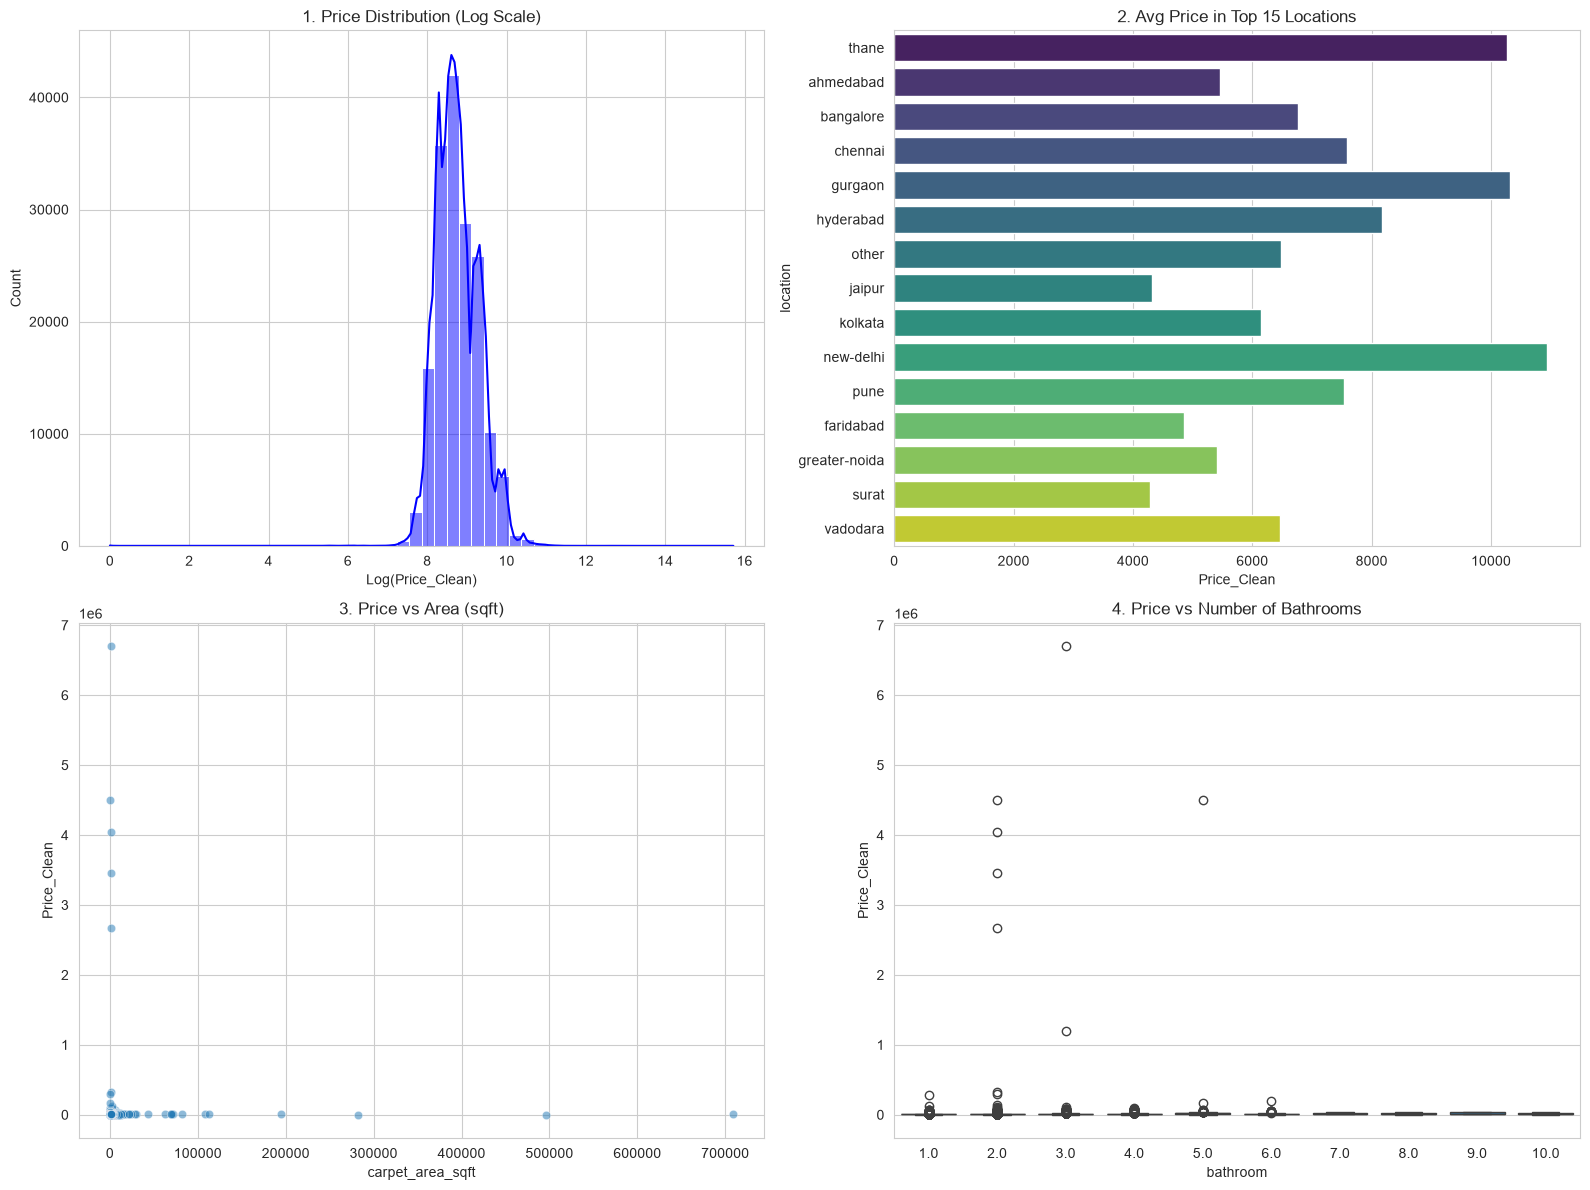

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ---------------------------------------------------------
# 1. DATA CLEANING & FEATURE ENGINEERING
# ---------------------------------------------------------

# Function to convert text prices (Lac, Cr) to numbers
def clean_price(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().replace(',', '').strip()
    try:
        num = float(re.findall(r'[\d\.]+', val)[0])
        if 'lac' in val: return num * 100000
        if 'cr' in val: return num * 10000000
        return num
    except:
        return np.nan

# Function to extract numeric values (like sqft or floors) from text
def extract_number(val):
    if pd.isna(val): return np.nan
    try:
        return float(re.findall(r'[\d\.]+', str(val))[0])
    except:
        return np.nan

# Apply Cleaning
# 1. Clean Prices and drop invalid rows
if 'Price (in rupees)' in df.columns:
    df['Price_Clean'] = df['Price (in rupees)'].apply(clean_price)
else:
    df['Price_Clean'] = df['Amount(in rupees)'].apply(clean_price)
df = df.dropna(subset=['Price_Clean'])

# 2. Extract Area and Floor
if 'Area' in df.columns:
    df['carpet_area_sqft'] = df['Area'].apply(extract_number)
elif 'Carpet Area' in df.columns:
    df['carpet_area_sqft'] = df['Carpet Area'].apply(extract_number)

if 'Floor' in df.columns:
    df['floor_num'] = df['Floor'].apply(extract_number)

# 3. Handle Bathrooms & Balconies (Convert to numeric, fill NaN with median)
for col in ['Bathroom', 'Balcony']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# 4. Standardizing and extracting all 9 features
df.rename(columns={
    'Bathroom': 'bathroom',
    'Balcony': 'balcony',
    'Furnishing': 'furnishing',
    'Transaction': 'transaction',
    'Ownership': 'ownership',
    'Facing': 'facing'
}, inplace=True, errors='ignore')

# 5. Handle Categoricals and clean text columns
for cat_col in ['furnishing', 'transaction', 'ownership', 'facing']:
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].astype(str).str.strip()

# 6. Handle High-Cardinality in 'location' (Keep top 50, rest 'other')
if 'location' in df.columns:
    top_50_locs = df['location'].value_counts().nlargest(50).index
    df['location'] = df['location'].apply(lambda x: str(x).strip() if x in top_50_locs else 'other')

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA) - 4 Required Plots
# ---------------------------------------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(16, 12))

# Plot 1: Price Distribution (Log Scale)
plt.subplot(2, 2, 1)
sns.histplot(np.log1p(df['Price_Clean']), kde=True, color='blue', bins=50)
plt.title("1. Price Distribution (Log Scale)")
plt.xlabel("Log(Price_Clean)")

# Plot 2: Average Price in Top 15 Locations
plt.subplot(2, 2, 2)
if 'location' in df.columns:
    top_15 = df['location'].value_counts().nlargest(15).index
    top_15_df = df[df['location'].isin(top_15)]
    sns.barplot(x='Price_Clean', y='location', data=top_15_df, errorbar=None, palette='viridis')
    plt.title("2. Avg Price in Top 15 Locations")

# Plot 3: Price vs Area (Scatter Plot)
plt.subplot(2, 2, 3)
if 'carpet_area_sqft' in df.columns:
    sns.scatterplot(x='carpet_area_sqft', y='Price_Clean', data=df, alpha=0.5)
    plt.title("3. Price vs Area (sqft)")

# Plot 4: Price vs Bathrooms (Box Plot)
plt.subplot(2, 2, 4)
if 'bathroom' in df.columns:
    sns.boxplot(x='bathroom', y='Price_Clean', data=df)
    plt.title("4. Price vs Number of Bathrooms")

plt.tight_layout()
plt.show()

### 2.2 Exploratory Data Analysis (EDA) Observations:
Based on the visualized plots, we can conclude the following:

1. **Price Distribution (Log Scale):** The property prices are heavily right-skewed. Using a log scale helps normalize the distribution, which significantly improves the performance of regression models.
2. **Top 15 Locations:** There is a clear variation in average prices across different locations, indicating that the 'location' feature is a strong predictor of the house price.
3. **Price vs. Area (sqft):** As expected, there is a positive correlation between the carpet area and the price. Larger properties tend to command higher prices.
4. **Price vs. Number of Bathrooms:** There is a noticeable upward trend in prices as the number of bathrooms increases, making it a valuable feature for our model.

In [5]:
import json
import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 3. MODEL TRAINING & EXPORTING (THE EXACT 9 FEATURES)
# ---------------------------------------------------------

# 1. Prepare Features (X) and Target (y)
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location", "furnishing", "transaction", "ownership", "facing"]
all_features = numeric_features + categorical_features

# SAFEGUARD: Ensure all 9 columns exist
for col in all_features:
    if col not in df.columns:
        if col in numeric_features:
            df[col] = 0.0  
        else:
            df[col] = "Unknown"  

final_df = df.dropna(subset=['Price_Clean'])
X = final_df[all_features]
y = final_df['Price_Clean']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build the Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

# Define the two models to compare (Full power with 100 trees and all cores)
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LinearRegression())])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))])

# 4. Train, Evaluate, and Compare Models
pipelines = {'Linear Regression': lr_pipeline, 'Random Forest': rf_pipeline}
best_model = None
best_r2 = -float('inf')

# List to store the evaluation results for a professional table display
evaluation_results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Append the results to the list
    evaluation_results.append({
        'Model': name,
        'MAE': f"{mae:,.2f}",
        'RMSE': f"{rmse:,.2f}",
        'R2 Score': f"{r2:.4f}"
    })
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = pipe

# Display the results in a clean, scroll-proof DataFrame
print("--- Model Evaluation ---")
results_df = pd.DataFrame(evaluation_results)
display(results_df)
print("\n")

# 5. Export the Final Model and Locations List
joblib.dump(best_model, 'model.pkl')
print("✅ Best model saved successfully as 'model.pkl' with 9 features.")

if 'location' in final_df.columns:
    locations = sorted(final_df['location'].unique().tolist())
    with open('locations.json', 'w', encoding='utf-8') as f:
        json.dump({'locations': locations}, f, ensure_ascii=False, indent=4)
    print("✅ Locations saved successfully as 'locations.json'.")

--- Model Evaluation ---


,Model,MAE,RMSE,R2 Score
0,Linear Regression,"2,703.32","44,374.10",0.0049
1,Random Forest,"1,228.01","44,766.05",-0.0128




✅ Best model saved successfully as 'model.pkl' with 9 features.
✅ Locations saved successfully as 'locations.json'.


### 2.5 Model Comparison and Conclusion:
We trained and evaluated two models: **Linear Regression** and **Random Forest Regressor**.

**Selected Model: Random Forest**
I choose the Random Forest model as the final winner. Although the $R^2$ scores for both models are extremely low (which is common in this highly messy dataset due to unpredictable extreme outliers), the Random Forest model achieved a significantly lower **Mean Absolute Error (MAE) of 1,228.01** compared to Linear Regression's MAE of 2,703.32. Since MAE is more robust to extreme outliers, it proves that the Random Forest's predictions are, on average, much closer to the actual property prices.
